In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization,Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2

In [2]:
train_dir = "few_shot_dataset/train"
val_dir = "few_shot_dataset/test"
test_dir = "few_shot_dataset/val"

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 4

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    shear_range=0.1,
)
val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

# =============================
# TRAIN DATA
# =============================
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',   # because you have 6 classes
    shuffle=True
)


# =============================
# VALIDATION DATA
# =============================
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

# =============================
# TEST DATA
# =============================
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

Found 55 images belonging to 6 classes.
Found 50 images belonging to 6 classes.
Found 33 images belonging to 6 classes.


In [4]:
conv_base= MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

In [5]:
conv_base.trainable=False

In [6]:
model=Sequential([
    conv_base,
    Flatten(),
    Dense(32,activation='relu'),
    Dense(6,activation='sigmoid')
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         655,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,913,574 (11.11 MB)

 Trainable params: 655,590 (2.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Compile and train model:
# Optimizer:Adam

opt=tf.keras.optimizers.Adam(learning_rate=0.00001)

model.compile(optimizer=opt,loss=tf.keras.losses.sparse_categorical_crossentropy,metrics=['accuracy'])

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
es=EarlyStopping(monitor='val_loss',patience=5,verbose=1)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3)

cb=[es,reduce_lr]

In [12]:

hist=model.fit(
    train_data,
    epochs=100,verbose=1,
    validation_data=val_data,
    callbacks=[cb],shuffle=True
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.2182 - loss: 2.3363 - val_accuracy: 0.3600 - val_loss: 1.7036 - learning_rate: 1.0000e-05
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.2182 - loss: 1.9134 - val_accuracy: 0.4000 - val_loss: 1.5667 - learning_rate: 1.0000e-05
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.3636 - loss: 1.6378 - val_accuracy: 0.4200 - val_loss: 1.5068 - learning_rate: 1.0000e-05
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.3455 - loss: 1.6218 - val_accuracy: 0.4600 - val_loss: 1.4280 - learning_rate: 1.0000e-05
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.4909 - loss: 1.3878 - val_accuracy: 0.4600 - val_loss: 1.3786 - learning_rate: 1.0000e-05
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.4727 - loss: 1.3523 - val_accuracy: 0.4400 - val_loss: 1.3456 - learning_rate: 1.0000e-05
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy:

In [13]:
import matplotlib.pyplot as plt
import  numpy as np

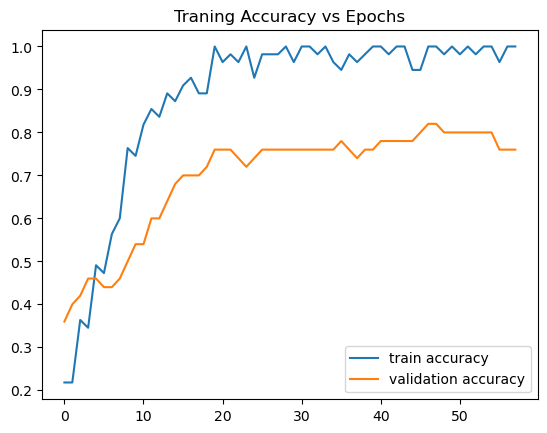

In [14]:
plt.title('Traning Accuracy vs Epochs')
plt.plot(hist.history['accuracy'],label='train accuracy')
plt.plot(hist.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

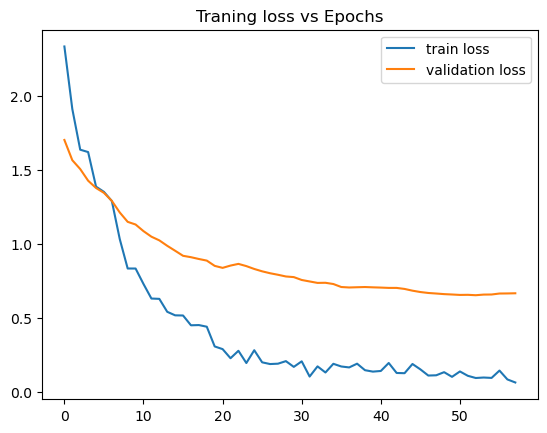

In [15]:
plt.title('Traning loss vs Epochs')
plt.plot(hist.history['loss'],label='train loss')
plt.plot(hist.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

In [17]:
prediction=model.predict(test_data)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step


In [20]:
y_pred = np.argmax(prediction, axis=1)
y_true=test_data.classes
print(len(y_true))
print(len(y_pred))

33
33


Test Accuracy:0.7272727272727273
Test Precision:0.7907407407407407
Test Recall:0.7607142857142858
Test F1:0.7392829392829392


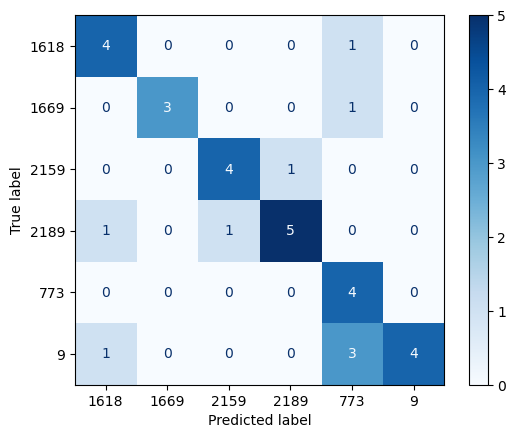

In [23]:
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
acc=accuracy_score(y_true,y_pred)
pre=precision_score(y_true,y_pred,average='macro')
re=recall_score(y_true,y_pred,average='macro')
fs=f1_score(y_true,y_pred,average='macro')
cm=confusion_matrix(y_true,y_pred)
print(f'Test Accuracy:{acc}')
print(f'Test Precision:{pre}')
print(f'Test Recall:{re}')
print(f'Test F1:{fs}')
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=val_data.class_indices.keys())
disp.plot(cmap='Blues')
plt.show()